## Code to analytically calculate curvature of soft ribbed sheets

### Imports 

In [35]:
import numpy as np
import matplotlib.pyplot as plt

### Model Dimensions


![Model Dimensions](Total.png) ![Model Dimensions](crossSec2.png)

In [ ]:
t = 0.9375          #mm
h = t               #mm    
w = t               #mm
d = t               #mm
l = t               #mm
L = 40              #mm


Phi = w/(w+d)
nu = 0.4
displacement  = (0.1*L)/L

### Calculating curvature
![Curvature](Chord.png)


In [43]:
kappa = ((6*t*h*Phi*(t+h))/((t**4) + (4*t**3)*h*Phi + 6*(t**2)*(h**2)*Phi + 4*t*(h**3)*Phi + (h**4)*(Phi)**2))*nu*displacement

Radius = 1/kappa

print(f"Phi = {Phi:.4f}")
print(f"kappa = {kappa:.6f} 1/mm")
print(f"Radius R = kappa^-1 = {Radius:.3f} mm")

Phi = 0.5000
kappa = 0.031030 1/mm
Radius R = kappa^-1 = 32.227 mm


### Visualization

In [54]:
def pretty_curvature_plot(Delta, R, *, ax=None, pad=0.25, title=None, unit="mm"):
    if Delta <= 0 or R <= 0:
        raise ValueError("Delta and R must be > 0")
    if Delta/2 >= R:
        raise ValueError("Need Delta/2 < R for a real circular arc.")

    kappa = 1.0 / R
    delta = R - np.sqrt(R**2 - (Delta/2)**2)

    # Geometry: chord on y=0, arc below. Circle center at (0, R-delta)
    cx, cy = 0.0, (R - delta)

    theta = np.arcsin((Delta/2)/R)
    tgrid = np.linspace(np.pi + theta, 2*np.pi - theta, 600)
    x_arc = cx + R*np.cos(tgrid)
    y_arc = cy + R*np.sin(tgrid)

    xL, xR = -Delta/2, Delta/2
    yC = 0.0
    yS = -delta

    if ax is None:
        fig, ax = plt.subplots(figsize=(9.2, 4.2), dpi=150)

    # Arc (thick, rounded)
    ax.plot(x_arc, y_arc, linewidth=6, solid_capstyle="round")

    # Chord line + endpoints
    ax.plot([xL, xR], [yC, yC], linewidth=2)
    ax.scatter([xL, xR], [yC, yC], s=45, zorder=5)

    # Δ arrow above chord + label
    y_arrow = 0.08*Delta
    ax.annotate("", xy=(xR, y_arrow), xytext=(xL, y_arrow),
                arrowprops=dict(arrowstyle="<->", linewidth=2.2, shrinkA=0, shrinkB=0))
    ax.text(0, y_arrow + 0.03*Delta, r"$\Delta$", ha="center", va="bottom", fontsize=16)

    # Midline dashed
    ax.plot([0, 0], [yS, y_arrow*1.15], linestyle=(0, (4, 4)), linewidth=1.6)

    # δ arrow + label
    ax.annotate("", xy=(0, yC), xytext=(0, yS),
                arrowprops=dict(arrowstyle="<->", linewidth=2.2, shrinkA=0, shrinkB=0))
    ax.text(0.03*Delta, (yC+yS)/2, r"$\delta$", ha="left", va="center", fontsize=16)

    # Radius vector to right endpoint
    ax.plot([cx, xR], [cy, yC], linewidth=3)
    ax.scatter([cx], [cy], s=55, zorder=6)
    ax.scatter([cx], [cy], s=160, alpha=0.12, zorder=5)

    # κ^{-1} label aligned with radius vector
    vx, vy = (xR - cx), (yC - cy)
    angle = np.degrees(np.arctan2(vy, vx))
    frac = 0.62
    lx, ly = cx + frac*vx, cy + frac*vy
    nlen = np.hypot(vx, vy)
    nx, ny = -vy/nlen, vx/nlen
    lx2, ly2 = lx + 0.05*Delta*nx, ly + 0.05*Delta*ny
    ax.text(lx2, ly2, r"$\kappa^{-1}$", rotation=angle, rotation_mode="anchor",
            ha="left", va="bottom", fontsize=16)

    # Info box
    info = (
        rf"$\Delta$ = {Delta:.3f} {unit}" "\n"
        rf"$\delta$ = {delta:.3f} {unit}" "\n"
        rf"$R=\kappa^{{-1}}$ = {R:.3f} {unit}" "\n"
        rf"$\kappa$ = {kappa:.6f} 1/{unit}"
    )
    ax.text(0.02, 0.98, info, transform=ax.transAxes, ha="left", va="top", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.4", linewidth=1.0, alpha=0.9))

    # Limits / framing
    xpad = (0.15 + pad)*Delta
    y_min = yS - (0.25 + pad)*max(delta, 0.15*Delta)
    y_max = y_arrow + (0.25 + pad)*Delta
    ax.set_xlim(xL - xpad, xR + xpad)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

    if title:
        ax.set_title(title, fontsize=14, pad=10)

    return ax



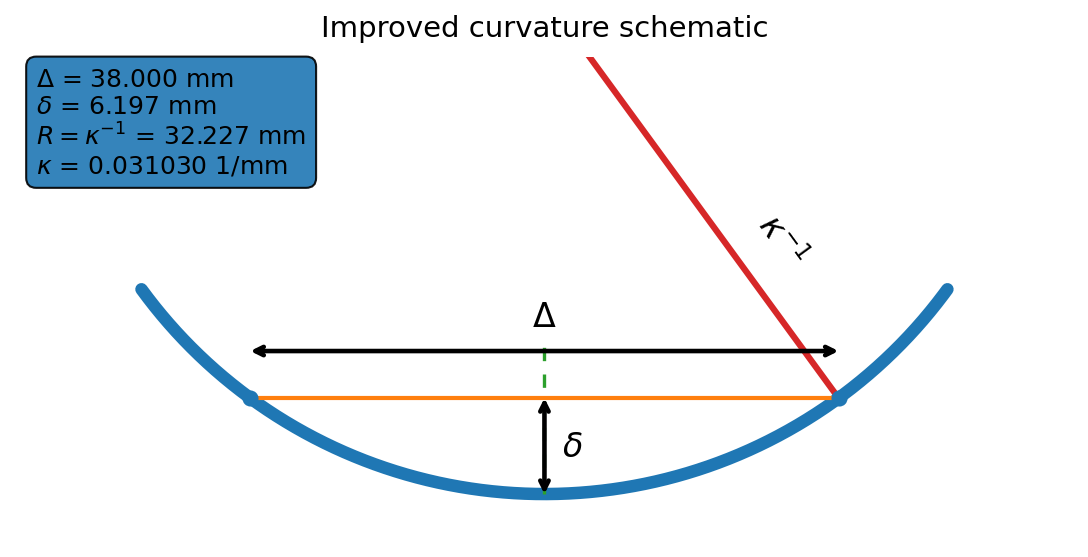

In [55]:
# Example (your shown values)
pretty_curvature_plot(Delta=38, R= Radius, title="Improved curvature schematic")
plt.show()

In [56]:
LT = 40e-3
NT = 128
a = 1e-3
svox = LT/NT
print(svox)
aV = round(a/svox)
aResov = aV * svox

print(aV)
print(aResov)



0.0003125
3
0.0009375
